In [152]:
import pandas as pd


In [153]:
df = pd.read_csv("../data/raw/raw_data.csv")

In [154]:
df.shape

(21273, 8)

In [155]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [156]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,140.519666,60.389968,19.369833,NaN,72.395542,7.916508,88.940006,cotton
1,NaN,21.072573,46.585469,30.119153,97.008824,6.479308,24.650713,muskmelon
2,51.668481,69.188181,21.245128,32.607020,NaN,7.111532,69.328985,blackgram
3,65.133280,62.570254,53.838735,30.443243,89.327208,6.326934,199.862354,papaya
4,5.879597,134.514423,197.421709,20.941375,92.824389,5.980268,NaN,apple


In [157]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,20226.000000,20197.000000,20201.000000,20225.000000,20193.000000,20220.000000,20196.000000
mean,50.657108,54.105815,51.626018,25.571138,72.765348,6.435002,102.668147
std,37.534206,35.334197,54.002302,5.361241,23.205424,0.788607,58.931233
min,0.000000,4.268002,4.364344,8.217962,12.905807,2.923178,17.630640
25%,20.378642,25.462353,20.407731,22.377992,61.306712,5.920874,62.371382
50%,36.463113,51.429654,35.650869,25.587495,81.233378,6.390613,96.657316
75%,86.296653,70.477597,50.665224,28.605390,89.477897,6.909774,121.763143
max,154.433076,168.387282,235.368165,51.960683,113.149599,10.879153,845.689962


In [158]:
df['humidity'] = df['humidity'].clip(lower=0, upper=100)

In [159]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,20226.000000,20197.000000,20201.000000,20225.000000,20193.000000,20220.000000,20196.000000
mean,50.657108,54.105815,51.626018,25.571138,72.716006,6.435002,102.668147
std,37.534206,35.334197,54.002302,5.361241,23.142802,0.788607,58.931233
min,0.000000,4.268002,4.364344,8.217962,12.905807,2.923178,17.630640
25%,20.378642,25.462353,20.407731,22.377992,61.306712,5.920874,62.371382
50%,36.463113,51.429654,35.650869,25.587495,81.233378,6.390613,96.657316
75%,86.296653,70.477597,50.665224,28.605390,89.477897,6.909774,121.763143
max,154.433076,168.387282,235.368165,51.960683,100.000000,10.879153,845.689962


In [160]:
df.isnull().sum()

N              1047
P              1076
K              1072
temperature    1048
humidity       1080
ph             1053
rainfall       1077
label             0
dtype: int64

In [161]:
cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Step 1: count nulls per row (only across these feature columns)
null_count = df[cols].isnull().sum(axis=1)

# Step 2: split into two groups
rows_to_fill = df[null_count == 1].copy()   # exactly 1 missing value → fill
rows_to_drop = df[null_count > 1]           # 2+ missing values → drop
rows_clean   = df[null_count == 0]          # already complete, keep as-is

print(f"Rows with 0 nulls (kept as-is): {len(rows_clean)}")
print(f"Rows with 1 null (median-filled): {len(rows_to_fill)}")
print(f"Rows with 2+ nulls (dropped): {len(rows_to_drop)}")

# Step 3: fill the single-null rows with column median
for col in cols:
    rows_to_fill[col] = rows_to_fill[col].fillna(df[col].median())

# Step 4: combine cleaned + filled rows, drop the rest
df = pd.concat([rows_clean, rows_to_fill], ignore_index=True)

print(f"Final row count: {len(df)}")

Rows with 0 nulls (kept as-is): 14847
Rows with 1 null (median-filled): 5489
Rows with 2+ nulls (dropped): 937
Final row count: 20336


In [162]:
df.duplicated().sum()

np.int64(0)

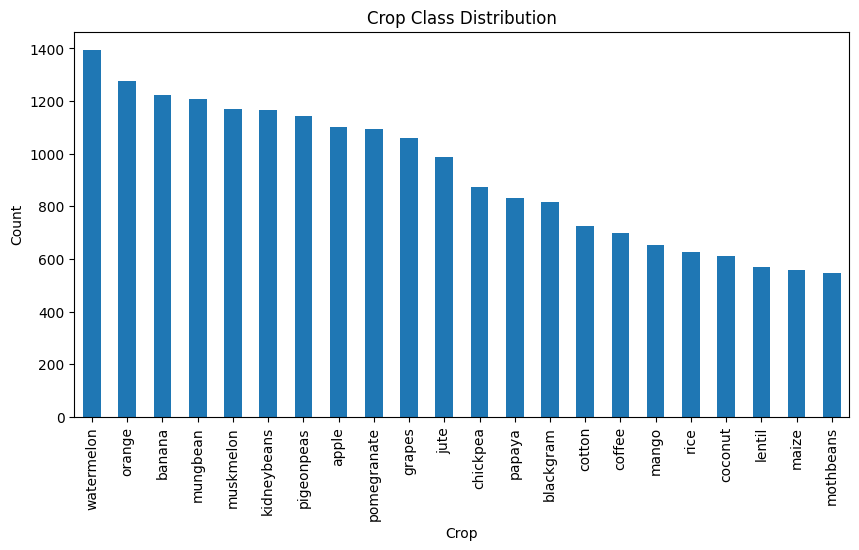

In [163]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Crop Class Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.show()

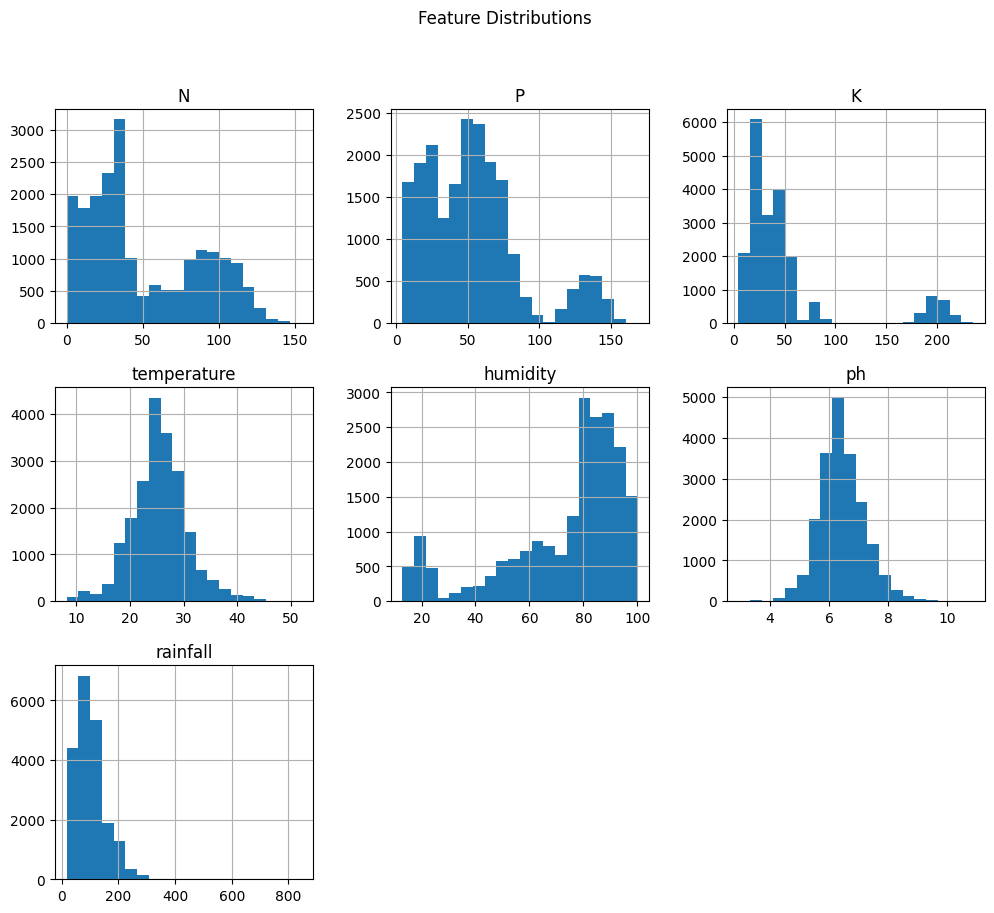

In [164]:
df.drop(columns=["label"]).hist(figsize=(12,10), bins=20)
plt.suptitle("Feature Distributions")
plt.show()


In [165]:
df[['N','P','K','temperature','humidity','ph','rainfall']].skew()

N              0.554881
P              0.961690
K              2.213804
temperature    0.179479
humidity      -1.216352
ph             0.302783
rainfall       2.255717
dtype: float64

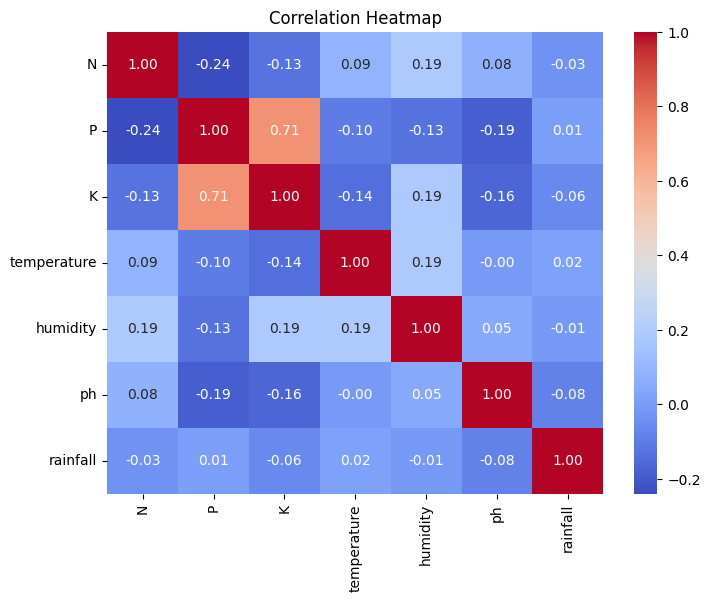

In [166]:
import seaborn as sns

corr = df.drop(columns=["label"]).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [167]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | range=({lower:.2f}, {upper:.2f})")

N: 0 outliers | range=(-74.96, 180.72)
P: 978 outliers | range=(-38.91, 134.61)
K: 2095 outliers | range=(-23.41, 94.33)
temperature: 874 outliers | range=(13.61, 37.36)
humidity: 1525 outliers | range=(22.24, 129.21)
ph: 466 outliers | range=(4.52, 8.31)
rainfall: 966 outliers | range=(-20.99, 204.80)


In [168]:
col = 'K'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# rows that WOULD get clipped by global IQR
would_be_clipped = df[(df[col] < lower) | (df[col] > upper)]

# which crops do these belong to?
print(would_be_clipped['label'].value_counts())


label
apple       1071
grapes      1019
chickpea       5
Name: count, dtype: int64


In [169]:
df["rainfall"].skew()

np.float64(2.2557170859043443)

In [170]:
import numpy as np
df["rainfall_log"] = np.log1p(df["rainfall"])

In [171]:
df["rainfall_log"].skew()

np.float64(-0.31594400325576544)

In [172]:
df["K"].skew()

np.float64(2.213803536306793)

In [173]:
df["K_log"] = np.log1p(df["K"])

In [174]:
df["K_log"].skew()

np.float64(0.6853184538377493)

In [175]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall,rainfall_log,K_log
count,20336.000000,20336.000000,20336.000000,20336.000000,20336.000000,20336.000000,20336.000000,20336.000000,20336.000000
mean,50.050132,54.035323,51.028398,25.559627,73.067627,6.432331,102.317879,4.495792,3.621097
std,36.905716,34.677423,53.049304,5.258178,22.721812,0.774651,57.738490,0.546351,0.752893
min,0.000000,4.268002,4.364344,8.217962,12.905807,2.923178,17.630640,2.924808,1.679774
25%,20.918984,26.160954,20.740372,22.514068,62.355019,5.938962,63.678922,4.169435,3.079171
50%,36.463113,51.429654,35.650869,25.587495,81.233378,6.390613,96.657316,4.581465,3.601437
75%,84.839085,69.542143,50.175980,28.452853,89.097982,6.887242,120.127211,4.796841,3.935270
max,154.433076,168.387282,235.368165,51.960683,100.000000,10.879153,845.689962,6.741335,5.465391
